# Phase 1: Data Validation & Integrity

## Objective
Ensure the dataset is:
- Structurally correct
- Statistically sound
- Behaviorally meaningful
- Free from leakage risks

## Why This Matters

Weak validation leads to:
- Misleading EDA
- Broken features
- Overfitted models
- False confidence in production

This notebook enforces **data trustworthiness before modeling**.

**1. SETUP AND IMPORTS**

In [1]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Stats
from scipy.stats import skew

# Config
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

# Add project root to path
import sys, os
sys.path.append(os.path.abspath(".."))

# Custom
from src.data.load_data import load_data

**2. LOAD DATA**

In [2]:
#define data paths
from pathlib import Path

DATA_DIR = Path("D:/PROJECTS/liquidity-stress-early-warning/data/raw")

train_df, test_df = load_data(
    train_path=DATA_DIR / "train.csv",
    test_path=DATA_DIR / "test.csv"
)


TRAIN DATA LOADED
Shape: (40000, 184)
Columns: 184
float64     134
int64        43
category      1
category      1
category      1
category      1
category      1
Int64         1
str           1
Name: count, dtype: int64


TEST DATA LOADED
Shape: (30000, 183)
Columns: 183
float64     134
int64        43
category      1
category      1
category      1
category      1
category      1
str           1
Name: count, dtype: int64

🔍 Validating TRAIN dataset...
✔ No duplicate IDs in TRAIN
✅ TRAIN validation completed.

🔍 Validating TEST dataset...
✔ No duplicate IDs in TEST
✅ TEST validation completed.



In [25]:
#view data

train_df.head(10)

,arpu,age,gender,region,smartphone,segment,earning_pattern,x_90_d_activity_rate,m1_paybill_volume,m1_paybill_total_value,m1_paybill_highest_amount,m1_paybill_companies,m2_paybill_volume,m2_paybill_total_value,m2_paybill_highest_amount,m2_paybill_companies,m3_paybill_volume,m3_paybill_total_value,m3_paybill_highest_amount,m3_paybill_companies,m4_paybill_volume,m4_paybill_total_value,m4_paybill_highest_amount,m4_paybill_companies,m5_paybill_volume,m5_paybill_total_value,m5_paybill_highest_amount,m5_paybill_companies,m6_paybill_volume,m6_paybill_total_value,m6_paybill_highest_amount,m6_paybill_companies,m1_merchantpay_volume,m1_merchantpay_total_value,m1_merchantpay_highest_amount,m1_merchantpay_merchants,m2_merchantpay_volume,m2_merchantpay_total_value,m2_merchantpay_highest_amount,m2_merchantpay_merchants,m3_merchantpay_volume,m3_merchantpay_total_value,m3_merchantpay_highest_amount,m3_merchantpay_merchants,m4_merchantpay_volume,m4_merchantpay_total_value,m4_merchantpay_highest_amount,m4_merchantpay_merchants,m5_merchantpay_volume,m5_merchantpay_total_value,m5_merchantpay_highest_amount,m5_merchantpay_merchants,m6_merchantpay_volume,m6_merchantpay_total_value,m6_merchantpay_highest_amount,m6_merchantpay_merchants,m1_transfer_from_bank_volume,m1_transfer_from_bank_total_value,m1_transfer_from_bank_highest_amount,m1_transfer_from_bank_banks,m2_transfer_from_bank_volume,m2_transfer_from_bank_total_value,m2_transfer_from_bank_highest_amount,m2_transfer_from_bank_banks,m3_transfer_from_bank_volume,m3_transfer_from_bank_total_value,m3_transfer_from_bank_highest_amount,m3_transfer_from_bank_banks,m4_transfer_from_bank_volume,m4_transfer_from_bank_total_value,m4_transfer_from_bank_highest_amount,m4_transfer_from_bank_banks,m5_transfer_from_bank_volume,m5_transfer_from_bank_total_value,m5_transfer_from_bank_highest_amount,m5_transfer_from_bank_banks,m6_transfer_from_bank_volume,m6_transfer_from_bank_total_value,m6_transfer_from_bank_highest_amount,m6_transfer_from_bank_banks,m1_mm_send_volume,m1_mm_send_total_value,m1_mm_send_highest_amount,m1_mm_send_recipients,m2_mm_send_volume,m2_mm_send_total_value,m2_mm_send_highest_amount,m2_mm_send_recipients,m3_mm_send_volume,m3_mm_send_total_value,m3_mm_send_highest_amount,m3_mm_send_recipients,m4_mm_send_volume,m4_mm_send_total_value,m4_mm_send_highest_amount,m4_mm_send_recipients,m5_mm_send_volume,m5_mm_send_total_value,m5_mm_send_highest_amount,m5_mm_send_recipients,m6_mm_send_volume,m6_mm_send_total_value,m6_mm_send_highest_amount,m6_mm_send_recipients,m1_received_volume,m1_received_total_value,m1_received_highest_amount,m1_received_senders,m2_received_volume,m2_received_total_value,m2_received_highest_amount,m2_received_senders,m3_received_volume,m3_received_total_value,m3_received_highest_amount,m3_received_senders,m4_received_volume,m4_received_total_value,m4_received_highest_amount,m4_received_senders,m5_received_volume,m5_received_total_value,m5_received_highest_amount,m5_received_senders,m6_received_volume,m6_received_total_value,m6_received_highest_amount,m6_received_senders,m1_deposit_volume,m1_deposit_total_value,m1_deposit_highest_amount,m1_deposit_agents,m2_deposit_volume,m2_deposit_total_value,m2_deposit_highest_amount,m2_deposit_agents,m3_deposit_volume,m3_deposit_total_value,m3_deposit_highest_amount,m3_deposit_agents,m4_deposit_volume,m4_deposit_total_value,m4_deposit_highest_amount,m4_deposit_agents,m5_deposit_volume,m5_deposit_total_value,m5_deposit_highest_amount,m5_deposit_agents,m6_deposit_volume,m6_deposit_total_value,m6_deposit_highest_amount,m6_deposit_agents,m1_withdraw_volume,m1_withdraw_total_value,m1_withdraw_highest_amount,m1_withdraw_agents,m2_withdraw_volume,m2_withdraw_total_value,m2_withdraw_highest_amount,m2_withdraw_agents,m3_withdraw_volume,m3_withdraw_total_value,m3_withdraw_highest_amount,m3_withdraw_agents,m4_withdraw_volume,m4_withdraw_total_value,m4_withdraw_highest_amount,m4_withdraw_agents,m5_withdraw_volume,m5_withdraw_total_value,m5_withdraw_highe

**3. SCHEMA & STRUCTURAL VALIDATION**

**Column Integrity**

In [3]:
# Check duplicate columns
duplicate_cols = train_df.columns[train_df.columns.duplicated()]
print("Duplicate Columns:", duplicate_cols.tolist())

# Check column consistency
print("Train Columns:", len(train_df.columns))
print("Test Columns:", len(test_df.columns))

missing_in_test = set(train_df.columns) - set(test_df.columns)
print("Missing in Test:", missing_in_test)

Duplicate Columns: []
Train Columns: 184
Test Columns: 183
Missing in Test: {'liquidity_stress_next_30d'}


**Data Types**

In [4]:
dtype_df = pd.DataFrame({
    "feature": train_df.columns,
    "dtype": train_df.dtypes.astype(str)
})

dtype_df.head(20)

,feature,dtype
arpu,arpu,float64
age,age,int64
gender,gender,category
region,region,category
smartphone,smartphone,category
segment,segment,category
earning_pattern,earning_pattern,category
x_90_d_activity_rate,x_90_d_activity_rate,float64
m1_paybill_volume,m1_paybill_volume,int64
m1_paybill_total_value,m1_paybill_total_value,float64


**4. DATA INTEGIRTY (ID Check)**

In [5]:
unique_ids = train_df["ID"].nunique()
total_rows = len(train_df)

print("Unique IDs:", unique_ids)
print("Total Rows:", total_rows)

assert unique_ids == total_rows, "❌ Duplicate IDs detected!"

Unique IDs: 40000
Total Rows: 40000


**Near_Duplicate check**

In [6]:
# Drop ID and target
feature_cols = [col for col in train_df.columns if col not in ["ID", "liquidity_stress_next_30d"]]

duplicates = train_df.duplicated(subset=feature_cols).sum()
print("Near-Duplicate Rows:", duplicates)

Near-Duplicate Rows: 0


**5. MISSING VALUES AUDIT**

In [7]:
missing_df = train_df.isnull().mean().sort_values(ascending=False)

missing_df = missing_df.reset_index()
missing_df.columns = ["feature", "missing_percentage"]

missing_df.sample(30)

,feature,missing_percentage
74,m5_transfer_from_bank_highest_amount,0.0
145,m5_deposit_total_value,0.0
105,m1_received_total_value,0.0
127,m6_received_senders,0.0
40,m3_merchantpay_volume,0.0
38,m2_merchantpay_highest_amount,0.0
1,age,0.0
96,m5_mm_send_volume,0.0
23,m4_paybill_companies,0.0
41,m3_merchantpay_total_value,0.0


**Missingness vs Target**

In [8]:
missing_target_corr = {}

for col in train_df.columns:
    missing_flag = train_df[col].isnull().astype(int)
    corr = missing_flag.corr(train_df["liquidity_stress_next_30d"])
    missing_target_corr[col] = corr

missing_target_corr_df = pd.Series(missing_target_corr).sort_values(ascending=False)
missing_target_corr_df.head(10)

c:\Users\otsyu\anaconda3\envs\Python_environment\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\otsyu\anaconda3\envs\Python_environment\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\otsyu\anaconda3\envs\Python_environment\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\otsyu\anaconda3\envs\Python_environment\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\otsyu\anaconda3\envs\Python_environment\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\otsyu\anaconda3\envs\Python_environment\Lib\site-packages\numpy\lib\_function_base_imp

arpu                     NaN
age                      NaN
gender                   NaN
region                   NaN
smartphone               NaN
segment                  NaN
earning_pattern          NaN
x_90_d_activity_rate     NaN
m1_paybill_volume        NaN
m1_paybill_total_value   NaN
dtype: float64

**Missing Heatmap**

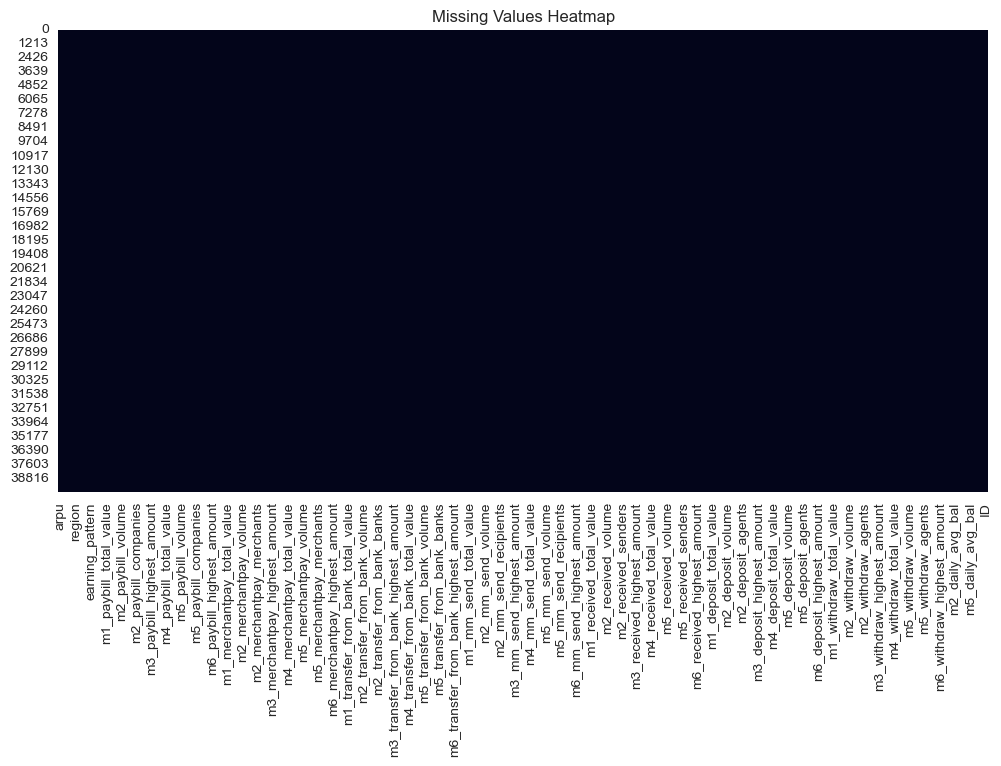

In [9]:
plt.figure(figsize=(12,6))
sns.heatmap(train_df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

**6. ZERO INFLATION ANALYSIS**

In [10]:
zero_pct = (train_df == 0).mean().sort_values(ascending=False) * 100
zero_pct.head(30)

liquidity_stress_next_30d                  85.0
m3_transfer_from_bank_highest_amount      73.25
m3_transfer_from_bank_banks               73.25
m3_transfer_from_bank_total_value         73.25
m3_transfer_from_bank_volume              73.25
m4_transfer_from_bank_highest_amount       73.2
m4_transfer_from_bank_banks                73.2
m4_transfer_from_bank_total_value          73.2
m4_transfer_from_bank_volume               73.2
m6_transfer_from_bank_total_value       73.0175
m6_transfer_from_bank_volume            73.0175
m6_transfer_from_bank_highest_amount    73.0175
m6_transfer_from_bank_banks             73.0175
m2_transfer_from_bank_total_value       72.7975
m2_transfer_from_bank_volume            72.7975
m2_transfer_from_bank_highest_amount    72.7975
m2_transfer_from_bank_banks             72.7975
m5_transfer_from_bank_highest_amount    72.7775
m5_transfer_from_bank_banks             72.7775
m5_transfer_from_bank_total_value       72.7775
m5_transfer_from_bank_volume            

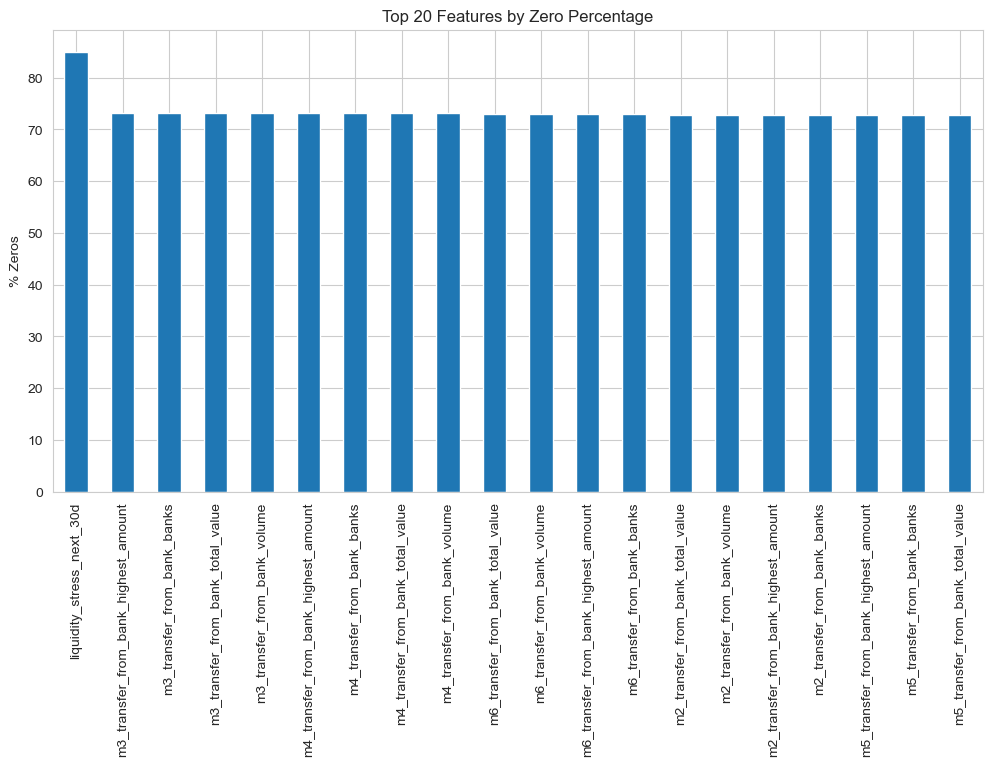

In [11]:
plt.figure(figsize=(12,6))
zero_pct.head(20).plot(kind='bar')
plt.title("Top 20 Features by Zero Percentage")
plt.ylabel("% Zeros")
plt.show()

**7. Distribution Analysis**

In [12]:
numeric_cols = train_df.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove("liquidity_stress_next_30d")

summary = pd.DataFrame({
    "feature": numeric_cols,
    "mean": train_df[numeric_cols].mean(),
    "std": train_df[numeric_cols].std(),
    "min": train_df[numeric_cols].min(),
    "max": train_df[numeric_cols].max(),
    "skewness": train_df[numeric_cols].apply(skew)
}).reset_index(drop=True)

summary.head(10)

,feature,mean,std,min,max,skewness
0,arpu,24480.982653,51992.965165,100.92,299815.19,3.548033
1,age,44.200500,15.322120,18.00,70.00,-0.021840
2,x_90_d_activity_rate,0.504210,0.229379,0.00,1.00,0.021897
3,m1_paybill_volume,3.178500,4.964303,0.00,41.00,2.111574
4,m1_paybill_total_value,33557.737733,124631.000620,0.00,2987089.24,7.022793
5,m1_paybill_highest_amount,3463.667285,8290.539405,0.00,49998.42,3.627111
6,m1_paybill_companies,2.127475,2.743577,0.00,8.00,0.912505
7,m2_paybill_volume,3.215975,5.029469,0.00,38.00,2.138226
8,m2_paybill_total_value,33662.161509,126804.218693,0.00,4202311.10,7.869942
9,m2_paybill_highest_amount,3520.387921,8465.908039,0.00,49997.31,3.615395


**Example Distribution Plot (Log Scale)**

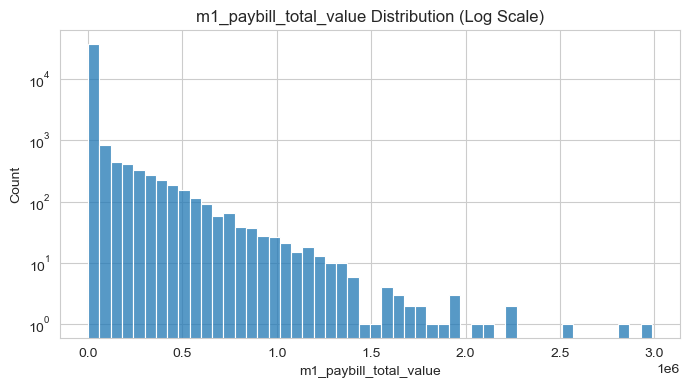

In [13]:
feature = "m1_paybill_total_value"

plt.figure(figsize=(8,4))
sns.histplot(train_df[feature], bins=50)
plt.yscale("log")
plt.title(f"{feature} Distribution (Log Scale)")
plt.show()

**8. Outlier Detection**

**IQR Method**

In [14]:
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return ((df[col] < lower) | (df[col] > upper)).mean()

outlier_ratios = {
    col: detect_outliers_iqr(train_df, col)
    for col in numeric_cols
}

outlier_df = pd.Series(outlier_ratios).sort_values(ascending=False)
outlier_df.head(10)

m3_transfer_from_bank_total_value       0.224975
m6_transfer_from_bank_total_value       0.224900
m2_transfer_from_bank_total_value       0.224325
m5_transfer_from_bank_total_value       0.222900
m4_transfer_from_bank_total_value       0.222775
m1_transfer_from_bank_total_value       0.222575
m2_transfer_from_bank_highest_amount    0.219075
m3_transfer_from_bank_highest_amount    0.218600
m6_transfer_from_bank_highest_amount    0.217975
m5_transfer_from_bank_highest_amount    0.217850
dtype: float64

**Boxplot Example**

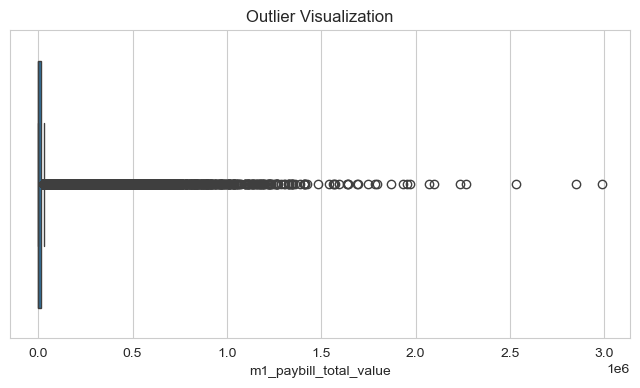

In [15]:
plt.figure(figsize=(8,4))
sns.boxplot(x=train_df["m1_paybill_total_value"])
plt.title("Outlier Visualization")
plt.show()

**9. Temporal Consistency Checks**

**Logical Rules**

In [16]:
violations = (train_df["m1_paybill_highest_amount"] > train_df["m1_paybill_total_value"]).sum()

print("Violations (highest > total):", violations)

Violations (highest > total): 0


**Volume vs Counterparties**

In [17]:
invalid = (train_df["m1_paybill_volume"] < train_df["m1_paybill_companies"]).sum()

print("Invalid Volume < Companies:", invalid)

Invalid Volume < Companies: 6682


**10. Target Variable Validation**

In [18]:
target_dist = train_df["liquidity_stress_next_30d"].value_counts(normalize=True)

print(target_dist)

liquidity_stress_next_30d
0    0.85
1    0.15
Name: proportion, dtype: Float64


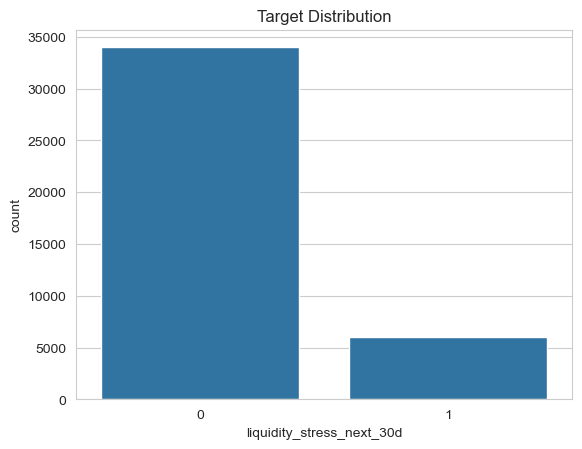

In [19]:
sns.countplot(x=train_df["liquidity_stress_next_30d"])
plt.title("Target Distribution")
plt.show()

**11. Correlation with target**

In [24]:
#clean target column

df = train_df.copy()

# Convert target to standard int
df["liquidity_stress_next_30d"] = df["liquidity_stress_next_30d"].astype(int)

#select only numeric column
numeric_df = df.select_dtypes(include=["number"])

#remove constant columns
# Drop columns with zero variance
numeric_df = numeric_df.loc[:, numeric_df.nunique() > 1]

#compute correlation
correlation = numeric_df.corr()["liquidity_stress_next_30d"].sort_values(ascending=False)

#drop target
correlation = correlation.drop("liquidity_stress_next_30d")

#view results
print("top 20 positive\n",correlation.head(20))   # top positive
print("\n\ntop 20 negative\n",correlation.tail(20))   # top negative

top 20 positive
 m6_daily_avg_bal              0.076690
m5_daily_avg_bal              0.072168
m4_daily_avg_bal              0.070079
m1_withdraw_volume            0.041631
m3_mm_send_total_value        0.033682
m3_withdraw_volume            0.032999
m4_deposit_total_value        0.032165
m5_deposit_total_value        0.032065
m3_withdraw_total_value       0.031102
m2_withdraw_volume            0.030917
m5_deposit_highest_amount     0.030817
m1_withdraw_total_value       0.030351
m6_mm_send_total_value        0.030344
m5_deposit_agents             0.030232
m1_withdraw_highest_amount    0.029132
m5_mm_send_highest_amount     0.029070
m4_received_total_value       0.028500
m1_paybill_total_value        0.027930
m6_deposit_total_value        0.027646
m4_received_highest_amount    0.027628
Name: liquidity_stress_next_30d, dtype: float64


top 20 negative
 m4_paybill_companies          -0.030562
m1_received_volume            -0.033057
m3_transfer_from_bank_banks   -0.034669
m1_transfer_from

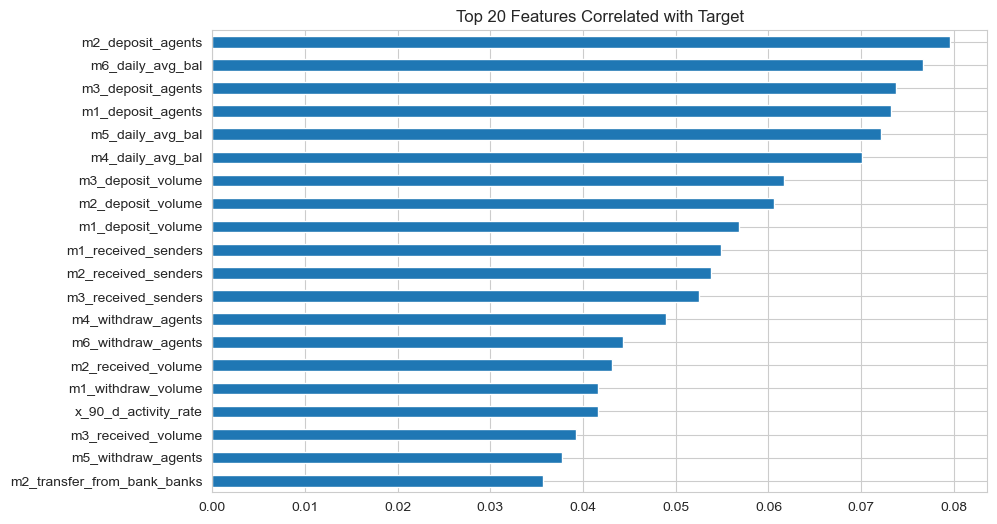

In [21]:
#visualize results

import matplotlib.pyplot as plt

top_features = correlation.abs().sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top_features.plot(kind="barh")
plt.title("Top 20 Features Correlated with Target")
plt.gca().invert_yaxis()
plt.show()

**11. Save Artifacts**

In [22]:
# Feature summary
feature_summary = summary.merge(missing_df, on="feature", how="left")
feature_summary = feature_summary.merge(zero_df, on="feature", how="left")

feature_summary.to_csv("D:/PROJECTS/liquidity-stress-early-warning/outputs/feature_summary.csv", index=False)

print("✅ feature_summary.csv saved")

NameError: name 'zero_df' is not defined

# 🧪 PHASE 1 SUMMARY: DATA VALIDATION & INTEGRITY

## 🎯 Objective Recap
This phase aimed to ensure that the dataset is:
- Structurally sound
- Statistically reliable
- Behaviorally interpretable
- Safe for downstream modeling

---

# 🧱 1. Dataset Overview

| Dataset | Rows | Columns |
|--------|------|--------|
| Train  | 40,000 | 184 |
| Test   | 30,000 | 183 |

- The test dataset is missing the target variable: `liquidity_stress_next_30d` ✔
- No duplicate columns detected ✔
- Feature alignment between train and test is consistent ✔

---

# 🧍 2. Entity Integrity

### ✅ ID Validation
- Unique IDs: **40,000**
- Total rows: **40,000**
- Duplicate IDs: **0**
- Near-duplicate rows: **0**

### 🧠 Insight
The dataset is **entity-clean**, with no duplication or leakage at the identifier level.  
This ensures reliable row-level modeling and prevents data contamination.

---

# 🕳️ 3. Missing Values Analysis

### ✅ Findings
- **0.0% missing values across ALL features**

### 🧠 Critical Interpretation
This dataset does **not use NaN to represent missingness**.

Instead:
> **Absence of activity is encoded as `0`**

### ⚠️ Implication
- Traditional missing value imputation is **NOT required**
- Missingness analysis shifts to **behavioral sparsity (zero inflation)**

---

# 🟡 4. Zero Inflation Analysis

### 🔍 Key Findings
- Many transactional features contain **>70% zeros**
- Example:
  - `transfer_from_bank_*` → ~73% zeros
  - `merchantpay_*` → ~57% zeros

### 🧠 Interpretation
> The dataset is **highly sparse and behavior-driven**

- Zero = **no activity**, not missing data
- Indicates:
  - Channel inactivity
  - User behavior patterns
  - Financial engagement levels

### 🚀 Implication
Zero values represent **strong predictive signals**, not noise.

---

# 📊 5. Distribution Analysis

### 🔍 Observations
- Most financial features exhibit:
  - **Extreme right skew**
  - **Heavy tails**
  - **Large variance**

Example:
- `m1_paybill_total_value`
  - Mean: ~33K
  - Max: ~2.9M
  - Skewness: **7.02**

### 🧠 Interpretation
> Data follows a **power-law distribution**, common in financial systems

- Small number of users dominate transaction volume
- Majority exhibit low or no activity

### ⚠️ Implication
- Linear models may struggle without transformation
- Log-scaling will be required in later stages

---

# 🚨 6. Outlier Analysis

### 🔍 Findings
- ~22% of observations flagged as outliers in some features

### 🧠 Interpretation
> These are likely **high-value customers (HVCs)**, not errors

### ⚠️ Recommendation
- DO NOT remove outliers blindly
- Treat them as:
  - Valuable signal
  - Key drivers of financial behavior

---

# 🔄 7. Temporal & Logical Consistency

### ✅ Valid Relationships
- `highest_amount ≤ total_value` → **0 violations**

### 🚨 Detected Issue
- **6,682 rows** where:

> transaction_volume < number_of_companies


### 🧠 Interpretation
This violates logical constraints:
- A user cannot transact with more entities than total transactions

### ⚠️ Implication
- Potential:
- Data quality issues
- Feature engineering inconsistencies

---

# 🎯 8. Target Variable Analysis

### 📊 Distribution
- Class 0: **85%**
- Class 1: **15%**

### 🧠 Interpretation
> Moderately imbalanced classification problem

### ⚠️ Implication
- Accuracy is not a reliable metric
- Need:
- ROC-AUC / PR-AUC
- Stratified validation
- Class balancing strategies

---

# ⚠️ 9. Statistical Warnings

### 🔍 Observed
- Runtime warnings during correlation analysis:

> invalid value encountered in divide


### 🧠 Root Cause
- Presence of **low-variance / constant features**

### ⚠️ Implication
- Some features may carry:
- No predictive signal
- Redundant information

---

# 🧠 Key Insights (Executive Summary)

### 🟢 Strengths
- Clean and consistent schema
- No missing values
- No duplicate entities
- Strong behavioral signal richness

### 🟡 Complexity
- Extreme zero inflation
- Highly skewed distributions
- Behavioral sparsity across users

### 🔴 Risks
- Logical inconsistencies in transactional features
- Potential low-variance features
- Heavy class imbalance

---

# 🚀 Strategic Direction for Next Phase

Based on validation findings, the next phase will focus on:

### 🔧 Feature Engineering Priorities
- Zero-aware feature construction (activity flags, engagement metrics)
- Log transformations for skewed distributions
- Handling low-variance features
- Addressing logical inconsistencies (volume vs entities)

### 🧠 Modeling Considerations
- Tree-based models preferred (robust to sparsity & skew)
- Imbalance-aware training strategies
- Behavioral feature extraction

---

# 🏁 Final Conclusion

> This dataset is not missing data — it is **behaviorally encoded data**.

The absence of activity (zeros), combined with heavy skew and transactional patterns, makes this a:

### 👉 **Behavioral Risk Modeling Problem**

Success in this project will depend on:
- Interpreting user behavior correctly
- Engineering meaningful activity-based features
- Leveraging sparsity as signal, not noise

---

📌 **Next Step:**  
Proceed to `02_feature_engineering.ipynb` to transform these insights into model-ready features.